# Overfitting minimal set of intervals

## imports

In [66]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODALITIES = {
    "rna_seq":        "#717EC3",
    "splice_site":    "#AE8799",
    "splice_usage":   "#C95D63",
    "splice_junctions": "#EE8434",
}

PAL_METRIC_GROUPS = {
    "gene_expr":    PAL_MODALITIES["rna_seq"],
    "splice_site":  PAL_MODALITIES["splice_site"],
    "ssu_pearson":  PAL_MODALITIES["splice_usage"],
    "junction_auprc": PAL_MODALITIES["splice_junctions"],
    "junction_count": PAL_MODALITIES["splice_junctions"],
    "psi5_pearson": PAL_MODALITIES["splice_usage"],
    "psi3_pearson": PAL_MODALITIES["splice_usage"],
}

PAL_RUNS      = {"alpha": "#333333", "alpha5": "#E8A838"}
RUN_LINESTYLE = {"alpha": "-",       "alpha5": ":"}
SUBSET_ALPHA_LEVEL = {"test": 1.0, "train_sample": 0.35}

## data

In [67]:
ROOT       = ".."
RESULTS_DIR  = os.path.join(ROOT, "results")
FINETUNE_DIR = os.path.join(ROOT, "results/bsc/finetuning/alphagenome_pytorch/full")
EVAL_DIR     = os.path.join(RESULTS_DIR, "bsc", "evaluation", "alphagenome_pytorch", "full")
logs_file    = os.path.join(FINETUNE_DIR, "summary", "epoch_logs.parquet")

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Both runs, mapped to short display labels
RUNS_OI = {
    "randinit__newloss__annotated__frozen__multigpu_ddp":          "alpha",
    "randinit__newloss__annotated__frozen__multigpu_ddp__alpha5":  "alpha5",
}
EPOCH_PRED = 10          # epoch used for scatter / delta plots
EPOCHS_OI  = [1, 2, 3, 4, 5, 10]
SUBSETS_OI = ["test", "train_sample"]

WT_SAMPLE  = "SRR17111303"
MUT_SAMPLE = "SRR17111311"

PRED_KEYS = [
    "rna_seq_per_gene", "splice_site_scores", "ssu_scores",
    "junction_totals",  "junction_scores",    "psi_scores",
]

In [68]:
logs = pd.read_parquet(logs_file)

# Predictions at EPOCH_PRED for each run: preds[label][key] = DataFrame
preds = {}
for run_name, label in RUNS_OI.items():
    preds_dir = os.path.join(EVAL_DIR, run_name, "epoch{}".format(EPOCH_PRED), "test", "predictions")
    preds[label] = {}
    for key in PRED_KEYS:
        fpath = os.path.join(preds_dir, "{}.parquet".format(key))
        if os.path.exists(fpath):
            preds[label][key] = pd.read_parquet(fpath)

# Metrics across epochs and subsets for both runs
metrics_epochs = []
for run_name, label in RUNS_OI.items():
    for epoch in EPOCHS_OI:
        for subset in SUBSETS_OI:
            fpath = os.path.join(EVAL_DIR, run_name, "epoch{}".format(epoch), subset, "metrics.parquet")
            if os.path.exists(fpath):
                df = pd.read_parquet(fpath)
                df["run_name"]  = run_name
                df["run_label"] = label
                df["epoch"]     = epoch
                df["subset"]    = subset
                metrics_epochs.append(df)
metrics_epochs = pd.concat(metrics_epochs, ignore_index=True)
print("metrics rows:", len(metrics_epochs))
print(metrics_epochs.value_counts(["run_label", "subset"]))

metrics rows: 744
run_label  subset      
alpha      test            186
           train_sample    186
alpha5     test            186
           train_sample    186
Name: count, dtype: int64


## figures

### evaluation metrics

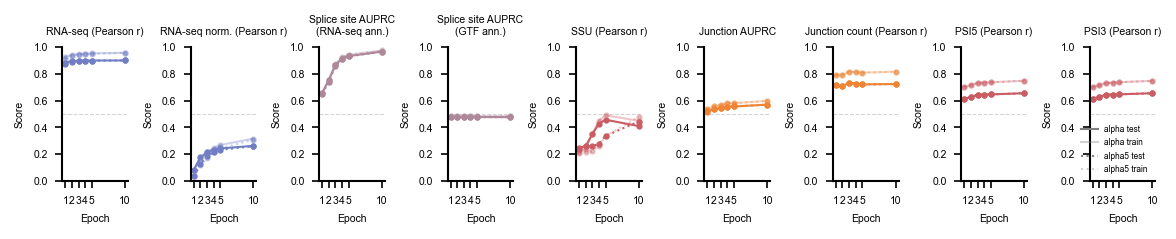

In [69]:
METRICS_OI = [
    "gene_expr_raw_mean",
    "gene_expr_norm_across_genes_mean",
    "splice_site_auprc_macro_rnaseq",
    "splice_site_auprc_macro_gtf",
    "ssu_pearson_r_mean",
    "junction_auprc_mean",
    "junction_count_pearson_r_mean",
    "psi5_pearson_r_mean",
    "psi3_pearson_r_mean",
]

MAP_LABELS = {
    "gene_expr_raw_mean":              "RNA-seq (Pearson r)",
    "gene_expr_norm_across_genes_mean":"RNA-seq norm. (Pearson r)",
    "splice_site_auprc_macro_rnaseq":  "Splice site AUPRC\n(RNA-seq ann.)",
    "splice_site_auprc_macro_gtf":     "Splice site AUPRC\n(GTF ann.)",
    "ssu_pearson_r_mean":              "SSU (Pearson r)",
    "junction_auprc_mean":             "Junction AUPRC",
    "junction_count_pearson_r_mean":   "Junction count (Pearson r)",
    "psi5_pearson_r_mean":             "PSI5 (Pearson r)",
    "psi3_pearson_r_mean":             "PSI3 (Pearson r)",
}

x = metrics_epochs.query("metric_name.isin(@METRICS_OI)")

n_metrics = len(METRICS_OI)
fig, axes = plt.subplots(1, n_metrics, figsize=(n_metrics * 2.2 * cm, 4 * cm), sharey=False)

for ax, metric_name in zip(axes, METRICS_OI):
    sub = x.query("metric_name == @metric_name")
    color = PAL_METRIC_GROUPS.get(sub["metric_group"].iloc[0], "gray")

    for run_label, run_grp in sub.groupby("run_label"):
        ls = RUN_LINESTYLE[run_label]
        for subset, sub_s in run_grp.groupby("subset"):
            alpha = SUBSET_ALPHA_LEVEL[subset]
            ax.plot(
                sub_s["epoch"], sub_s["value"],
                color=color, linewidth=1, marker="o", markersize=2,
                linestyle=ls, alpha=alpha,
            )

    ax.set_title(MAP_LABELS[metric_name], fontsize=5)
    ax.set_xlabel("Epoch", fontsize=5)
    ax.set_ylabel("Score", fontsize=5)
    ax.set_xticks(EPOCHS_OI)
    ax.tick_params(labelsize=5)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="lightgray", linestyle="--", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

# Legend: run (linestyle) × subset (opacity)
handles = []
for run_label, ls in RUN_LINESTYLE.items():
    handles.append(plt.Line2D([0], [0], color="gray", linewidth=1, linestyle=ls,
                              alpha=SUBSET_ALPHA_LEVEL["test"],    label="{} test".format(run_label)))
    handles.append(plt.Line2D([0], [0], color="gray", linewidth=1, linestyle=ls,
                              alpha=SUBSET_ALPHA_LEVEL["train_sample"], label="{} train".format(run_label)))
axes[-1].legend(handles=handles, fontsize=4, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evaluation_metrics.pdf"), bbox_inches="tight")
plt.show()

In [70]:
logs.value_counts(["run_name"])

run_name                                                  
randinit__newloss__annotated__frozen__multigpu_ddp            10
randinit__newloss__annotated__frozen__multigpu_ddp__alpha5    10
Name: count, dtype: int64

### splice site and junction heads struggle to overfit a single interval

In [71]:
X = logs#.query("run_name.isin(@runs_oi)")

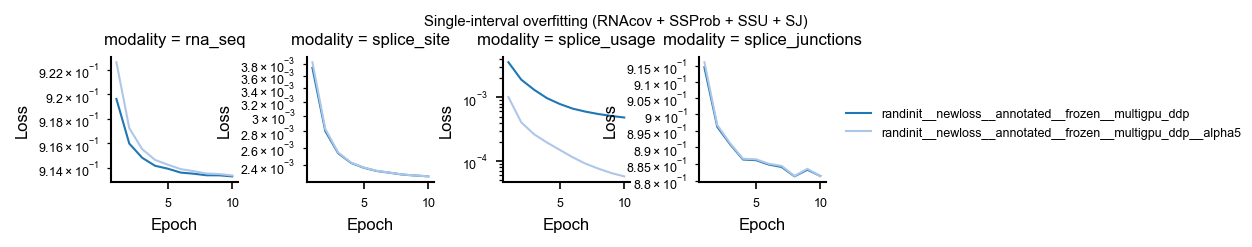

In [72]:
x = (
    X[
        ["epoch","run_name","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="modality", col_order=PAL_MODALITIES.keys(),
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

## performance on held-out intervals

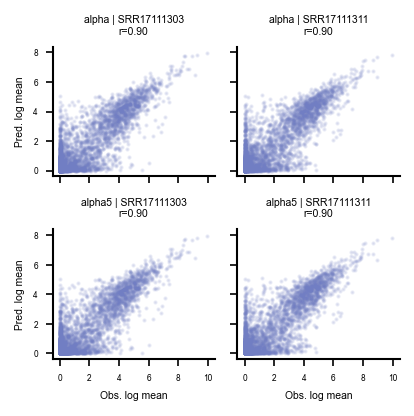

In [73]:
run_labels = list(RUNS_OI.values())
samples = [WT_SAMPLE, MUT_SAMPLE]

fig, axes = plt.subplots(
    len(run_labels), len(samples),
    figsize=(len(samples) * 3.5 * cm, len(run_labels) * 3.5 * cm),
    sharex=True, sharey=True,
)

for r_i, label in enumerate(run_labels):
    X = preds[label]["rna_seq_per_gene"]
    for c_i, sample in enumerate(samples):
        ax = axes[r_i, c_i]
        sub = X.query("track_name == @sample")
        r_val, _ = stats.pearsonr(sub["obs_log_mean"], sub["pred_log_mean"])
        ax.scatter(sub["obs_log_mean"], sub["pred_log_mean"],
                   s=1, alpha=0.15, rasterized=True, color=PAL_MODALITIES["rna_seq"])
        ax.set_title("{} | {}\nr={:.2f}".format(label, sample, r_val), fontsize=5)
        ax.tick_params(labelsize=4)
        if c_i == 0:
            ax.set_ylabel("Pred. log mean", fontsize=5)
        if r_i == len(run_labels) - 1:
            ax.set_xlabel("Obs. log mean", fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

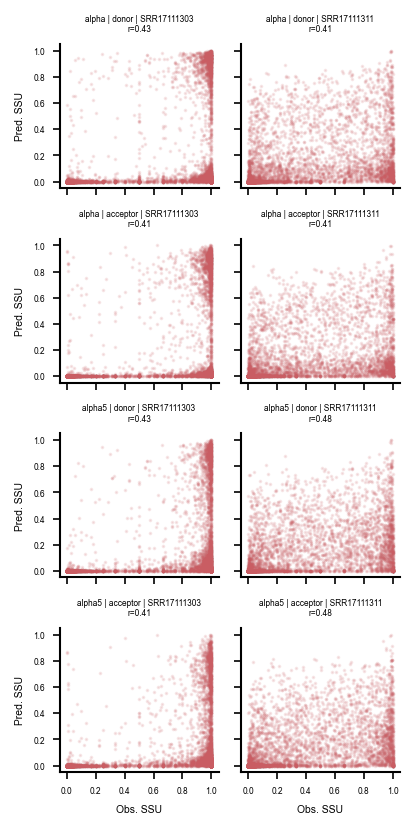

In [74]:
roles = ["donor", "acceptor"]
n_rows = len(run_labels) * len(roles)
n_cols = len(samples)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3.5 * cm, n_rows * 3.5 * cm),
    sharex=True, sharey=True,
)

for r_i, label in enumerate(run_labels):
    X = preds[label]["ssu_scores"].sample(min(20000, len(preds[label]["ssu_scores"])), random_state=42)
    for role_i, role in enumerate(roles):
        row = r_i * len(roles) + role_i
        for c_i, sample in enumerate(samples):
            ax = axes[row, c_i]
            sub = X.query("sample_id == @sample and role == @role").dropna(subset=["obs_ssu","pred_ssu"])
            r_val, _ = stats.pearsonr(sub["obs_ssu"], sub["pred_ssu"])
            ax.scatter(sub["obs_ssu"], sub["pred_ssu"],
                       s=0.5, alpha=0.15, rasterized=True, color=PAL_MODALITIES["splice_usage"])
            ax.set_title("{} | {} | {}\nr={:.2f}".format(label, role, sample, r_val), fontsize=4)
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.tick_params(labelsize=4)
            if c_i == 0:
                ax.set_ylabel("Pred. SSU", fontsize=5)
            if row == n_rows - 1:
                ax.set_xlabel("Obs. SSU", fontsize=5)
            sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [75]:
# Quick sanity: highest-obs_ssu rows per run
for label in run_labels:
    print("--- {} ---".format(label))
    print(preds[label]["ssu_scores"].sort_values("obs_ssu").tail(3).to_string())
    print()

--- alpha ---
         chrom  exon_pos_1based strand      role    sample_id  pred_ssu  obs_ssu
47        chr3         31056991      -     donor  SRR17111303  0.000013      1.0
4        chr20          7996071      -     donor  SRR17111303  0.025879      1.0
1692640   chr8        104588819      -  acceptor  SRR17111303  0.015381      1.0

--- alpha5 ---
         chrom  exon_pos_1based strand      role    sample_id  pred_ssu  obs_ssu
47        chr3         31056991      -     donor  SRR17111303  0.000021      1.0
4        chr20          7996071      -     donor  SRR17111303  0.026367      1.0
1692640   chr8        104588819      -  acceptor  SRR17111303  0.020386      1.0



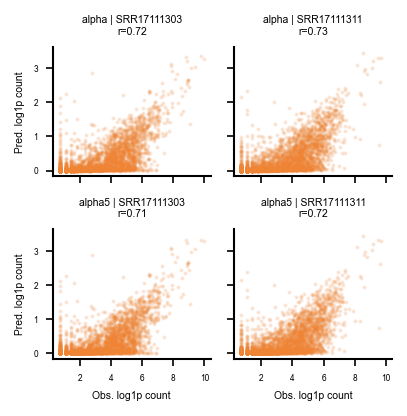

In [76]:
fig, axes = plt.subplots(
    len(run_labels), len(samples),
    figsize=(len(samples) * 3.5 * cm, len(run_labels) * 3.5 * cm),
    sharex=True, sharey=True,
)

for r_i, label in enumerate(run_labels):
    X = (
        preds[label]["junction_scores"]
        .query("obs_count > 0")
        .sample(min(10000, len(preds[label]["junction_scores"].query("obs_count > 0"))), random_state=42)
        .assign(obs_log1p=lambda d: np.log1p(d["obs_count"]),
                pred_log1p=lambda d: np.log1p(d["pred_count"]))
    )
    for c_i, sample in enumerate(samples):
        ax = axes[r_i, c_i]
        sub = X.query("sample_id == @sample").dropna(subset=["obs_log1p","pred_log1p"])
        r_val, _ = stats.pearsonr(sub["obs_log1p"], sub["pred_log1p"])
        ax.scatter(sub["obs_log1p"], sub["pred_log1p"],
                   s=1, alpha=0.15, rasterized=True, color=PAL_MODALITIES["splice_junctions"])
        ax.set_title("{} | {}\nr={:.2f}".format(label, sample, r_val), fontsize=5)
        ax.tick_params(labelsize=4)
        if c_i == 0:
            ax.set_ylabel("Pred. log1p count", fontsize=5)
        if r_i == len(run_labels) - 1:
            ax.set_xlabel("Obs. log1p count", fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## WT vs MUT delta

In [77]:
KEY_GENE   = "gene_id"
KEY_SSU    = ["chrom", "exon_pos_1based", "strand", "role"]
KEY_JUNC   = ["chrom", "donor_pos_1based", "acceptor_pos_1based", "strand"]

### RNA-seq gene expression delta

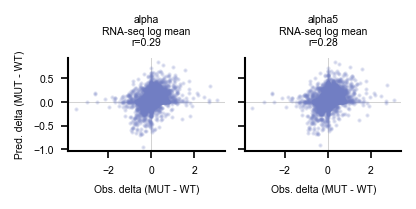

In [78]:
fig, axes = plt.subplots(1, len(run_labels), figsize=(len(run_labels) * 3.5 * cm, 3.5 * cm), sharey=True, sharex=True)

for ax, label in zip(axes, run_labels):
    X = preds[label]["rna_seq_per_gene"]
    wt  = X.query("track_name == @WT_SAMPLE").set_index(KEY_GENE)[["obs_log_mean","pred_log_mean"]]
    mut = X.query("track_name == @MUT_SAMPLE").set_index(KEY_GENE)[["obs_log_mean","pred_log_mean"]]
    delta = pd.DataFrame({
        "obs_delta":  mut["obs_log_mean"]  - wt["obs_log_mean"],
        "pred_delta": mut["pred_log_mean"] - wt["pred_log_mean"],
    }).dropna()
    r, _ = stats.pearsonr(delta["obs_delta"], delta["pred_delta"])
    ax.scatter(delta["obs_delta"], delta["pred_delta"],
               s=1, alpha=0.2, rasterized=True, color=PAL_MODALITIES["rna_seq"])
    ax.set_title("{}\nRNA-seq log mean\nr={:.2f}".format(label, r), fontsize=5)
    ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
    ax.tick_params(labelsize=5)
    ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
    ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

axes[0].set_ylabel("Pred. delta (MUT - WT)", fontsize=5)
plt.tight_layout()
plt.show()

### SSU delta

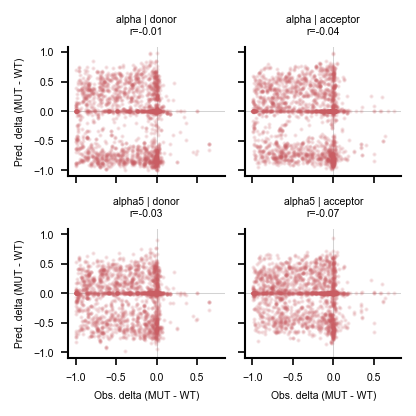

In [79]:
fig, axes = plt.subplots(
    len(run_labels), len(roles),
    figsize=(len(roles) * 3.5 * cm, len(run_labels) * 3.5 * cm),
    sharex=True, sharey=True,
)

for r_i, label in enumerate(run_labels):
    X = preds[label]["ssu_scores"].sample(min(30000, len(preds[label]["ssu_scores"])), random_state=42)
    wt  = X.query("sample_id == @WT_SAMPLE").set_index(KEY_SSU)[["obs_ssu","pred_ssu"]]
    mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY_SSU)[["obs_ssu","pred_ssu"]]
    delta_ssu = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner")
    delta_ssu["obs_delta"]  = delta_ssu["obs_ssu_mut"]  - delta_ssu["obs_ssu_wt"]
    delta_ssu["pred_delta"] = delta_ssu["pred_ssu_mut"] - delta_ssu["pred_ssu_wt"]
    delta_ssu = delta_ssu.reset_index().dropna(subset=["obs_delta","pred_delta"])

    for c_i, role in enumerate(roles):
        ax = axes[r_i, c_i]
        sub = delta_ssu.query("role == @role").sample(min(10000, len(delta_ssu.query("role == @role"))), random_state=42)
        r_val, _ = stats.pearsonr(sub["obs_delta"], sub["pred_delta"])
        ax.scatter(sub["obs_delta"], sub["pred_delta"],
                   s=1, alpha=0.15, rasterized=True, color=PAL_MODALITIES["splice_usage"])
        ax.set_title("{} | {}\nr={:.2f}".format(label, role, r_val), fontsize=5)
        ax.tick_params(labelsize=5)
        ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
        ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
        if c_i == 0:
            ax.set_ylabel("Pred. delta (MUT - WT)", fontsize=5)
        if r_i == len(run_labels) - 1:
            ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Junction count delta

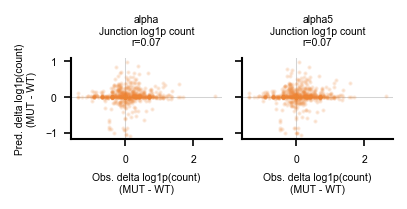

In [80]:
fig, axes = plt.subplots(1, len(run_labels), figsize=(len(run_labels) * 3.5 * cm, 3.5 * cm), sharey=True, sharex=True)

for ax, label in zip(axes, run_labels):
    X = (
        preds[label]["junction_scores"]
        .query("obs_count > 0")
        .sample(min(10000, len(preds[label]["junction_scores"].query("obs_count > 0"))), random_state=42)
    )
    wt  = X.query("sample_id == @WT_SAMPLE").set_index(KEY_JUNC)[["obs_count","pred_count"]]
    mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY_JUNC)[["obs_count","pred_count"]]
    delta_junc = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner")
    delta_junc = delta_junc.query("obs_count_wt > 0 or obs_count_mut > 0")
    delta_junc["obs_delta"]  = np.log1p(delta_junc["obs_count_mut"])  - np.log1p(delta_junc["obs_count_wt"])
    delta_junc["pred_delta"] = np.log1p(delta_junc["pred_count_mut"]) - np.log1p(delta_junc["pred_count_wt"])
    delta_junc = delta_junc.dropna(subset=["obs_delta","pred_delta"])
    sub = delta_junc.sample(min(10000, len(delta_junc)), random_state=42)
    r_val, _ = stats.pearsonr(sub["obs_delta"], sub["pred_delta"])
    ax.scatter(sub["obs_delta"], sub["pred_delta"],
               s=1, alpha=0.15, rasterized=True, color=PAL_MODALITIES["splice_junctions"])
    ax.set_title("{}\nJunction log1p count\nr={:.2f}".format(label, r_val), fontsize=5)
    ax.set_xlabel("Obs. delta log1p(count)\n(MUT - WT)", fontsize=5)
    ax.tick_params(labelsize=5)
    ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
    ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

axes[0].set_ylabel("Pred. delta log1p(count)\n(MUT - WT)", fontsize=5)
plt.tight_layout()
plt.show()

### PSI delta (PSI5 and PSI3)

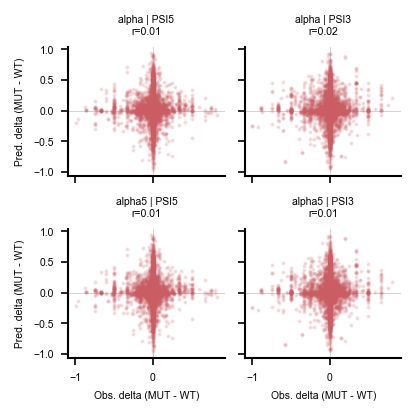

In [81]:
psi_types = [("PSI5", "obs_psi5", "pred_psi5"), ("PSI3", "obs_psi3", "pred_psi3")]

fig, axes = plt.subplots(
    len(run_labels), len(psi_types),
    figsize=(len(psi_types) * 3.5 * cm, len(run_labels) * 3.5 * cm),
    sharex=True, sharey=True,
)

for r_i, label in enumerate(run_labels):
    X = preds[label]["psi_scores"].sample(min(30000, len(preds[label]["psi_scores"])), random_state=42)
    wt  = X.query("sample_id == @WT_SAMPLE").set_index(KEY_JUNC)[["obs_psi5","pred_psi5","obs_psi3","pred_psi3"]]
    mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY_JUNC)[["obs_psi5","pred_psi5","obs_psi3","pred_psi3"]]
    delta_psi = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner").reset_index()

    for c_i, (psi_label, obs_col, pred_col) in enumerate(psi_types):
        ax = axes[r_i, c_i]
        obs_d  = delta_psi[obs_col + "_mut"]  - delta_psi[obs_col + "_wt"]
        pred_d = delta_psi[pred_col + "_mut"] - delta_psi[pred_col + "_wt"]
        valid  = pd.DataFrame({"obs": obs_d, "pred": pred_d}).dropna()
        sub    = valid.sample(min(10000, len(valid)), random_state=42)
        r_val, _ = stats.pearsonr(sub["obs"], sub["pred"])
        ax.scatter(sub["obs"], sub["pred"],
                   s=1, alpha=0.15, rasterized=True, color=PAL_MODALITIES["splice_usage"])
        ax.set_title("{} | {}\nr={:.2f}".format(label, psi_label, r_val), fontsize=5)
        ax.tick_params(labelsize=5)
        ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
        ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
        if c_i == 0:
            ax.set_ylabel("Pred. delta (MUT - WT)", fontsize=5)
        if r_i == len(run_labels) - 1:
            ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Summary figure — all modalities

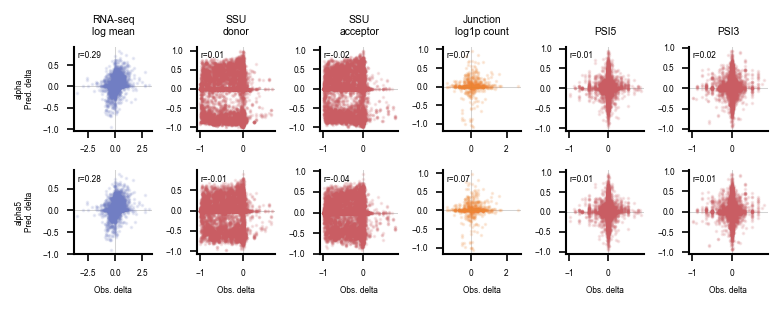

In [82]:
PANEL_DEFS = [
    {"title": "RNA-seq\nlog mean",    "color": PAL_MODALITIES["rna_seq"],
     "obs": "obs_delta",  "pred": "pred_delta"},
    {"title": "SSU\ndonor",           "color": PAL_MODALITIES["splice_usage"],
     "obs": "obs_delta",  "pred": "pred_delta"},
    {"title": "SSU\nacceptor",        "color": PAL_MODALITIES["splice_usage"],
     "obs": "obs_delta",  "pred": "pred_delta"},
    {"title": "Junction\nlog1p count","color": PAL_MODALITIES["splice_junctions"],
     "obs": "obs_delta",  "pred": "pred_delta"},
    {"title": "PSI5",                 "color": PAL_MODALITIES["splice_usage"],
     "obs": "obs_psi5_delta", "pred": "pred_psi5_delta"},
    {"title": "PSI3",                 "color": PAL_MODALITIES["splice_usage"],
     "obs": "obs_psi3_delta", "pred": "pred_psi3_delta"},
]

n_rows = len(run_labels)
n_cols = len(PANEL_DEFS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2 * cm, n_rows * 2.6 * cm))

for r_i, label in enumerate(run_labels):
    # Precompute deltas for this run
    rna = preds[label]["rna_seq_per_gene"]
    wt_rna  = rna.query("track_name == @WT_SAMPLE").set_index(KEY_GENE)[["obs_log_mean","pred_log_mean"]]
    mut_rna = rna.query("track_name == @MUT_SAMPLE").set_index(KEY_GENE)[["obs_log_mean","pred_log_mean"]]
    delta_rna = pd.DataFrame({
        "obs_delta":  mut_rna["obs_log_mean"]  - wt_rna["obs_log_mean"],
        "pred_delta": mut_rna["pred_log_mean"] - wt_rna["pred_log_mean"],
    }).dropna()

    ssu = preds[label]["ssu_scores"].sample(min(60000, len(preds[label]["ssu_scores"])), random_state=42)
    wt_ssu  = ssu.query("sample_id == @WT_SAMPLE").set_index(KEY_SSU)[["obs_ssu","pred_ssu"]]
    mut_ssu = ssu.query("sample_id == @MUT_SAMPLE").set_index(KEY_SSU)[["obs_ssu","pred_ssu"]]
    delta_ssu = wt_ssu.join(mut_ssu, lsuffix="_wt", rsuffix="_mut", how="inner").reset_index()
    delta_ssu["obs_delta"]  = delta_ssu["obs_ssu_mut"]  - delta_ssu["obs_ssu_wt"]
    delta_ssu["pred_delta"] = delta_ssu["pred_ssu_mut"] - delta_ssu["pred_ssu_wt"]

    junc = preds[label]["junction_scores"].query("obs_count > 0").sample(
        min(10000, len(preds[label]["junction_scores"].query("obs_count > 0"))), random_state=42)
    wt_j  = junc.query("sample_id == @WT_SAMPLE").set_index(KEY_JUNC)[["obs_count","pred_count"]]
    mut_j = junc.query("sample_id == @MUT_SAMPLE").set_index(KEY_JUNC)[["obs_count","pred_count"]]
    delta_junc = wt_j.join(mut_j, lsuffix="_wt", rsuffix="_mut", how="inner")
    delta_junc["obs_delta"]  = np.log1p(delta_junc["obs_count_mut"])  - np.log1p(delta_junc["obs_count_wt"])
    delta_junc["pred_delta"] = np.log1p(delta_junc["pred_count_mut"]) - np.log1p(delta_junc["pred_count_wt"])
    delta_junc = delta_junc.dropna(subset=["obs_delta","pred_delta"])

    psi = preds[label]["psi_scores"].sample(min(30000, len(preds[label]["psi_scores"])), random_state=42)
    wt_psi  = psi.query("sample_id == @WT_SAMPLE").set_index(KEY_JUNC)[["obs_psi5","pred_psi5","obs_psi3","pred_psi3"]]
    mut_psi = psi.query("sample_id == @MUT_SAMPLE").set_index(KEY_JUNC)[["obs_psi5","pred_psi5","obs_psi3","pred_psi3"]]
    delta_psi = wt_psi.join(mut_psi, lsuffix="_wt", rsuffix="_mut", how="inner").reset_index()
    delta_psi["obs_psi5_delta"]  = delta_psi["obs_psi5_mut"]  - delta_psi["obs_psi5_wt"]
    delta_psi["pred_psi5_delta"] = delta_psi["pred_psi5_mut"] - delta_psi["pred_psi5_wt"]
    delta_psi["obs_psi3_delta"]  = delta_psi["obs_psi3_mut"]  - delta_psi["obs_psi3_wt"]
    delta_psi["pred_psi3_delta"] = delta_psi["pred_psi3_mut"] - delta_psi["pred_psi3_wt"]

    data_map = [
        delta_rna,
        delta_ssu.query("role == 'donor'"),
        delta_ssu.query("role == 'acceptor'"),
        delta_junc.reset_index(),
        delta_psi,
        delta_psi,
    ]

    for c_i, (panel, data) in enumerate(zip(PANEL_DEFS, data_map)):
        ax = axes[r_i, c_i]
        df  = data[[panel["obs"], panel["pred"]]].dropna()
        sub = df.sample(min(10000, len(df)), random_state=42)
        r_val, _ = stats.pearsonr(sub[panel["obs"]], sub[panel["pred"]])
        ax.scatter(sub[panel["obs"]], sub[panel["pred"]],
                   s=0.5, alpha=0.15, rasterized=True, color=panel["color"])
        ax.text(0.05, 0.95, "r={:.2f}".format(r_val), transform=ax.transAxes, fontsize=4, va="top")
        ax.tick_params(labelsize=4)
        ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
        ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
        if c_i == 0:
            ax.set_ylabel("{}\nPred. delta".format(label), fontsize=4)
        if r_i == n_rows - 1:
            ax.set_xlabel("Obs. delta", fontsize=4)
        if r_i == 0:
            ax.set_title(panel["title"], fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "wt_mut_delta.pdf"), bbox_inches="tight")
plt.show()